🔹 Loading images...
✅ Loaded 71400 images with shape (71400, 4096) and 34 classes.
⚙️ Training Logistic Regression model...


c:\Users\darik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\darik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



📊 Evaluation Metrics:
Accuracy: 0.8520
Precision: 0.8525, Recall: 0.8520, F1: 0.8520

Classification Report:
               precision    recall  f1-score   support

     class_1     0.9374    0.9233    0.9303       600
    class_10     0.7608    0.7055    0.7321       275
    class_11     0.8168    0.8500    0.8331       320
    class_12     0.8125    0.7748    0.7932       302
    class_13     0.7981    0.7943    0.7962       423
    class_14     0.8252    0.7461    0.7837       386
    class_15     0.6939    0.7596    0.7253       391
    class_16     0.6860    0.6921    0.6891       341
    class_17     0.7959    0.7626    0.7789       358
    class_18     0.7836    0.8102    0.7967       353
    class_19     0.7971    0.7971    0.7971       340
     class_2     0.7378    0.7246    0.7311       334
    class_20     0.7259    0.7327    0.7293       318
    class_21     0.8127    0.7920    0.8022       274
    class_22     0.9019    0.8883    0.8950       600
    class_23     0.9831 

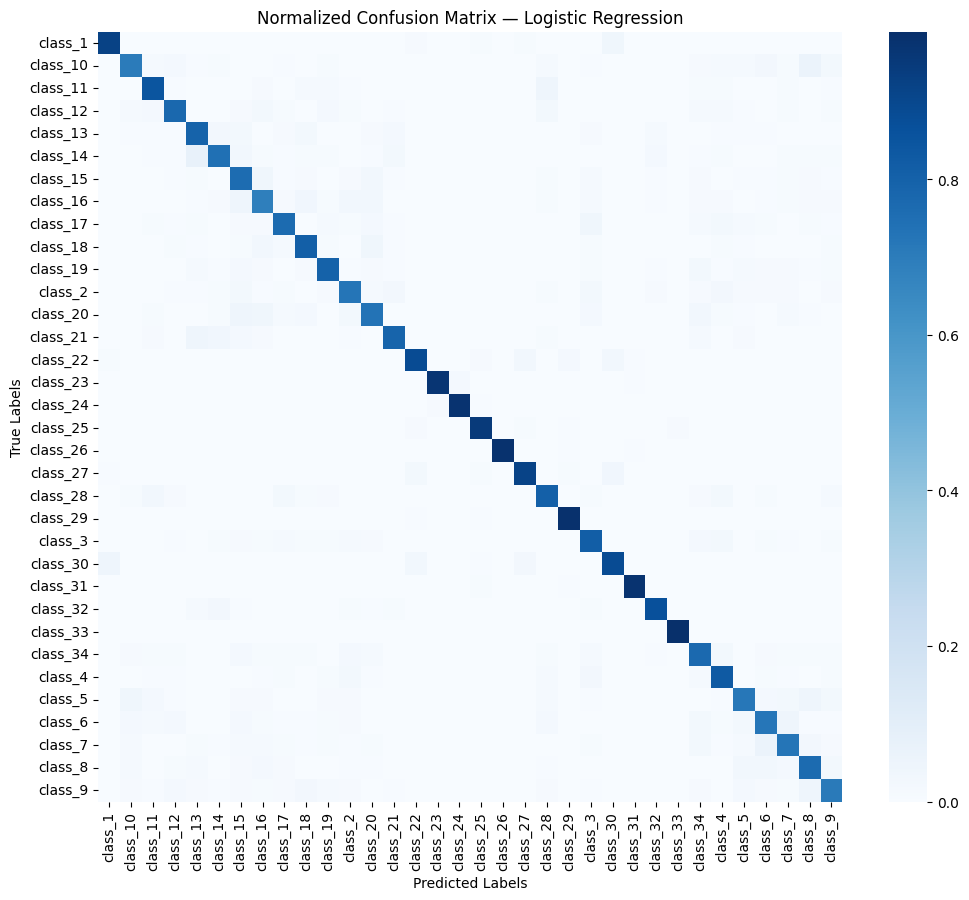

In [ ]:

# KURDISH SIGN LANGUAGE (KuSL2023)
# Logistic Regression Model — Grayscale Version


import os, time
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# CONFIGURATION

DATA_DIR = r"C:\Datasets\kurdish_sign_dataset"
IMG_SIZE = (64, 64)
REPORT_PATH = r"C:\Datasets\reports\kurdish_sign_logreg_report.txt"


# STEP 1 — Load and Preprocess Dataset (Grayscale)

X, y = [], []
print("🔹 Loading images...")

for label in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, label)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # convert to grayscale
            img = cv2.resize(img, IMG_SIZE)
            X.append(img.flatten())  # flatten to 1D vector
            y.append(label)
        except Exception as e:
            print("❌ Error reading:", img_path, e)

X = np.array(X)
y = np.array(y)

print(f"✅ Loaded {len(X)} images with shape {X.shape} and {len(np.unique(y))} classes.")


# STEP 2 — Encode and Scale

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


# STEP 3 — Train Logistic Regression Model

print("⚙️ Training Logistic Regression model...")
start = time.time()
logreg = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
logreg.fit(X_train, y_train)
train_time = time.time() - start


# STEP 4 — Evaluate

y_pred = logreg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
report = classification_report(y_test, y_pred, target_names=le.classes_, digits=4)

print("\n📊 Evaluation Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
print("\nClassification Report:\n", report)

# Save report
os.makedirs(os.path.dirname(REPORT_PATH), exist_ok=True)
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(f"Training time: {train_time:.2f}s\n")
    f.write(f"Accuracy: {acc:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1: {f1:.4f}\n\n")
    f.write(report)
print(f"✅ Report saved at: {REPORT_PATH}")


# STEP 5 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Normalized Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
